# DAY 2 · 배터리 수명 예측 모델 개발 및 평가

**문제:** 초기 100사이클까지의 정보로 셀의 총수명 `cycle_life`를 회귀 예측한다. Batch 1의 충전정책 그룹 분리 CV로 모델을 고르고, 별도 Hold-out과 Batch 2에서 순서대로 평가한다. Batch 3은 추가 평가다.

DAY 1 전략은 [모델 설계 보고서](../report/DAY1_모델설계.pdf), 실행 가능한 구현은 [`src/day2_modeling.py`](../src/day2_modeling.py)에 있다. 현재 노트북은 `data/processed/`의 저장된 초기 피처를 사용하므로 대용량 원본 MAT가 없어도 재실행할 수 있다.

## 1. 재현 환경·고정 데이터

데이터는 셀당 한 행이다. 라벨 유효성과 종료 용량 기준은 DAY 1에서 고정했고, 29/7셀 분할과 CV fold도 저장된 파일을 그대로 사용한다. 피처 화이트리스트는 수명·종료값·전체 기록으로 계산한 knee·식별자를 차단한다.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if ROOT.name == "notebooks": ROOT = ROOT.parent
assert (ROOT / "src/day2_modeling.py").is_file(), "프로젝트 루트나 notebooks 폴더에서 실행하세요"
sys.path.insert(0, str(ROOT / "src"))
import day2_modeling as day2
train, holdout, external, plan = day2.load_data(ROOT)
print("Python:", sys.executable)
display(pd.DataFrame([
    {"partition":"Train/CV", "cells":len(train), "policy_groups":train.policy_group.nunique()},
    {"partition":"Valid/Hold-out", "cells":len(holdout), "policy_groups":holdout.policy_group.nunique()},
    *[{"partition":b, "cells":len(g), "policy_groups":g.policy_group.nunique()} for b,g in external.items()],
]))
print("Batch 1 train/valid group overlap:", len(set(train.policy_group)&set(holdout.policy_group)))
print("CV fold sizes:", train.cv_fold.value_counts().sort_index().to_dict())

Python: /Users/dogyun/Downloads/ess_day1/.venv/bin/python


,partition,cells,policy_groups
0,Train/CV,29,16
1,Valid/Hold-out,7,4
2,Batch 2,39,9
3,Batch 3,44,8


Batch 1 train/valid group overlap: 0
CV fold sizes: {1.0: 6, 2.0: 6, 3.0: 6, 4.0: 6, 5.0: 5}


## 2. DAY 1 전략 → 모델 후보

- **G0:** ΔQ의 log10 분산. 세 배치에서 수명과 일관된 음의 관계가 나온 초기 신호다.
- **G1~G3:** 초기 용량 기울기, 충전시간·첫 단계 C-rate, 평균 온도를 순서대로 추가한다.
- **G4:** G0에 공통 2~5사이클의 시간 가중 RMS 전류를 별도로 추가한다.

Ridge/ElasticNet은 작은 표본과 중복 신호에 대응하고, 얕은 Random Forest·Gradient Boosting은 제한된 비선형 후보로 비교한다. 원 수명과 log 수명 타깃은 같은 CV fold에서 비교한다. 모든 결측 대체·표준화는 각 fold의 학습 부분에서만 적합된다.

In [2]:
run = day2.run(ROOT)
print("선택 사양:", run["winner"]["id"])
print("중앙값 기준 CV MAPE (%):", round(pd.read_csv(ROOT / "results/day2_baseline_folds.csv").mape_pct.mean(),2))
display(run["candidates"][["feature_set","model","settings","target_scale","cv_mape_pct","cv_mape_sd_pct"]].head(10).round(2))

Selected: G0_delta__Ridge__alpha=0.1__raw
                   index    n   mape_pct  mape_sd_pct  mae_cycles  rmse_cycles
      Train (Batch 1 CV) 29.0   7.931271     1.875723   64.684437    84.210340
Valid (Batch 1 Hold-out)  7.0  10.758097          NaN   88.555081    96.564313
          Test (Batch 2) 39.0  25.688237          NaN  129.583940   153.225446
       Gap (Train-Valid)  NaN   2.826825          NaN         NaN          NaN
        Gap (Valid-Test)  NaN  14.930140          NaN         NaN          NaN
       Gap (Target-Test)  NaN  16.588237          NaN         NaN          NaN
          Test (Batch 3) 44.0  12.078507          NaN  146.501189   237.970586
   Gap (Batch 2-Batch 3)  NaN -13.609731          NaN         NaN          NaN
선택 사양: G0_delta__Ridge__alpha=0.1__raw
중앙값 기준 CV MAPE (%): 17.08


,feature_set,model,settings,target_scale,cv_mape_pct,cv_mape_sd_pct
0,G0_delta,Ridge,alpha=0.1,raw,7.93,1.88
1,G0_delta,ElasticNet,"alpha=0.01,l1=0.5",raw,7.93,1.88
2,G0_delta,ElasticNet,"alpha=0.1,l1=0.5",raw,7.98,1.92
3,G4_current,ElasticNet,"alpha=0.1,l1=0.5",raw,8.22,1.80
4,G0_delta,ElasticNet,"alpha=0.01,l1=0.5",log,8.24,2.00
5,G0_delta,Ridge,alpha=0.1,log,8.25,1.93
6,G4_current,ElasticNet,"alpha=0.01,l1=0.5",raw,8.35,1.68
7,G4_current,Ridge,alpha=0.1,raw,8.36,1.68
8,G4_current,Ridge,alpha=0.1,log,8.38,1.37
9,G4_current,ElasticNet,"alpha=0.01,l1=0.5",log,8.45,1.42


## 3. 가이드 형식의 성능 결과

Train은 Batch 1 학습 29셀의 5-fold CV 평균, Valid는 모델 사양 선택 후 Hold-out 7셀의 1회 평가다. Batch 2는 사양을 고정하고 Batch 1의 36셀로 재학습한 뒤 평가한다. Gap은 **Valid−CV**, **Batch 2−Valid**, **Batch 2−9.1%** 순서로 계산하며 단위는 %p다. 9.1%는 논문 비교 기준이지 이 프로젝트가 달성한 값이 아니다.

In [3]:
performance = pd.read_csv(ROOT / "results/day2_performance.csv")
display(performance.round(2))
with open(ROOT / "results/day2_selected_model.json") as handle:
    selected = json.load(handle)
print("Batch 2 정책군 부트스트랩 MAPE 95% 탐색 구간:", [round(x,2) for x in selected["batch2_mape_policy_cluster_ci95"]])

,index,n,mape_pct,mape_sd_pct,mae_cycles,rmse_cycles
0,Train (Batch 1 CV),29.0,7.93,1.88,64.68,84.21
1,Valid (Batch 1 Hold-out),7.0,10.76,NaN,88.56,96.56
2,Test (Batch 2),39.0,25.69,NaN,129.58,153.23
3,Gap (Train-Valid),NaN,2.83,NaN,NaN,NaN
4,Gap (Valid-Test),NaN,14.93,NaN,NaN,NaN
5,Gap (Target-Test),NaN,16.59,NaN,NaN,NaN
6,Test (Batch 3),44.0,12.08,NaN,146.50,237.97
7,Gap (Batch 2-Batch 3),NaN,-13.61,NaN,NaN,NaN


Batch 2 정책군 부트스트랩 MAPE 95% 탐색 구간: [17.9, 35.18]


## 4. 예측 오차와 배치 차이

Batch 2에는 Batch 1 Train의 실제 수명 범위보다 짧은 셀이 30개다. 이 구간과 충전정책별로 모델이 어느 방향으로 틀리는지 살펴본다. 수명 범위 밖이라는 사실만으로 입력 변수까지 외삽이라고 단정하지 않는다.

Batch 2 실제 수명 구간별


,cells,MAPE_pct,mean_bias_cycles
target_range,,,
above_train,2,7.41,-85.46
below_train,30,28.76,128.81
within_train,7,17.76,142.15


Batch 3 실제 수명 구간별


,cells,MAPE_pct,mean_bias_cycles
target_range,,,
above_train,17,15.89,-231.36
within_train,27,9.68,49.65


Batch 2 오차 상위 10셀


,cell_id,actual,predicted,absolute_percentage_error,policy_group
46,b2c18,449.0,744.41,65.79,5.2|0.5|4.25
71,b2c6,393.0,651.09,65.67,3.6|0.09|5
43,b2c15,396.0,643.83,62.58,3.6|0.09|5
48,b2c2,424.0,614.35,44.89,5.2|0.5|4.25
56,b2c29,452.0,639.62,41.51,5.2|0.58|4
39,b2c11,449.0,627.58,39.77,5.2|0.5|4.25
51,b2c24,514.0,709.44,38.02,4.8|0.8|4.8
74,b2c9,791.0,1079.81,36.51,5.6|0.26|4.5
55,b2c28,437.0,594.95,36.15,4.8|0.8|4.8
45,b2c17,471.0,635.46,34.92,5.6|0.26|4.5


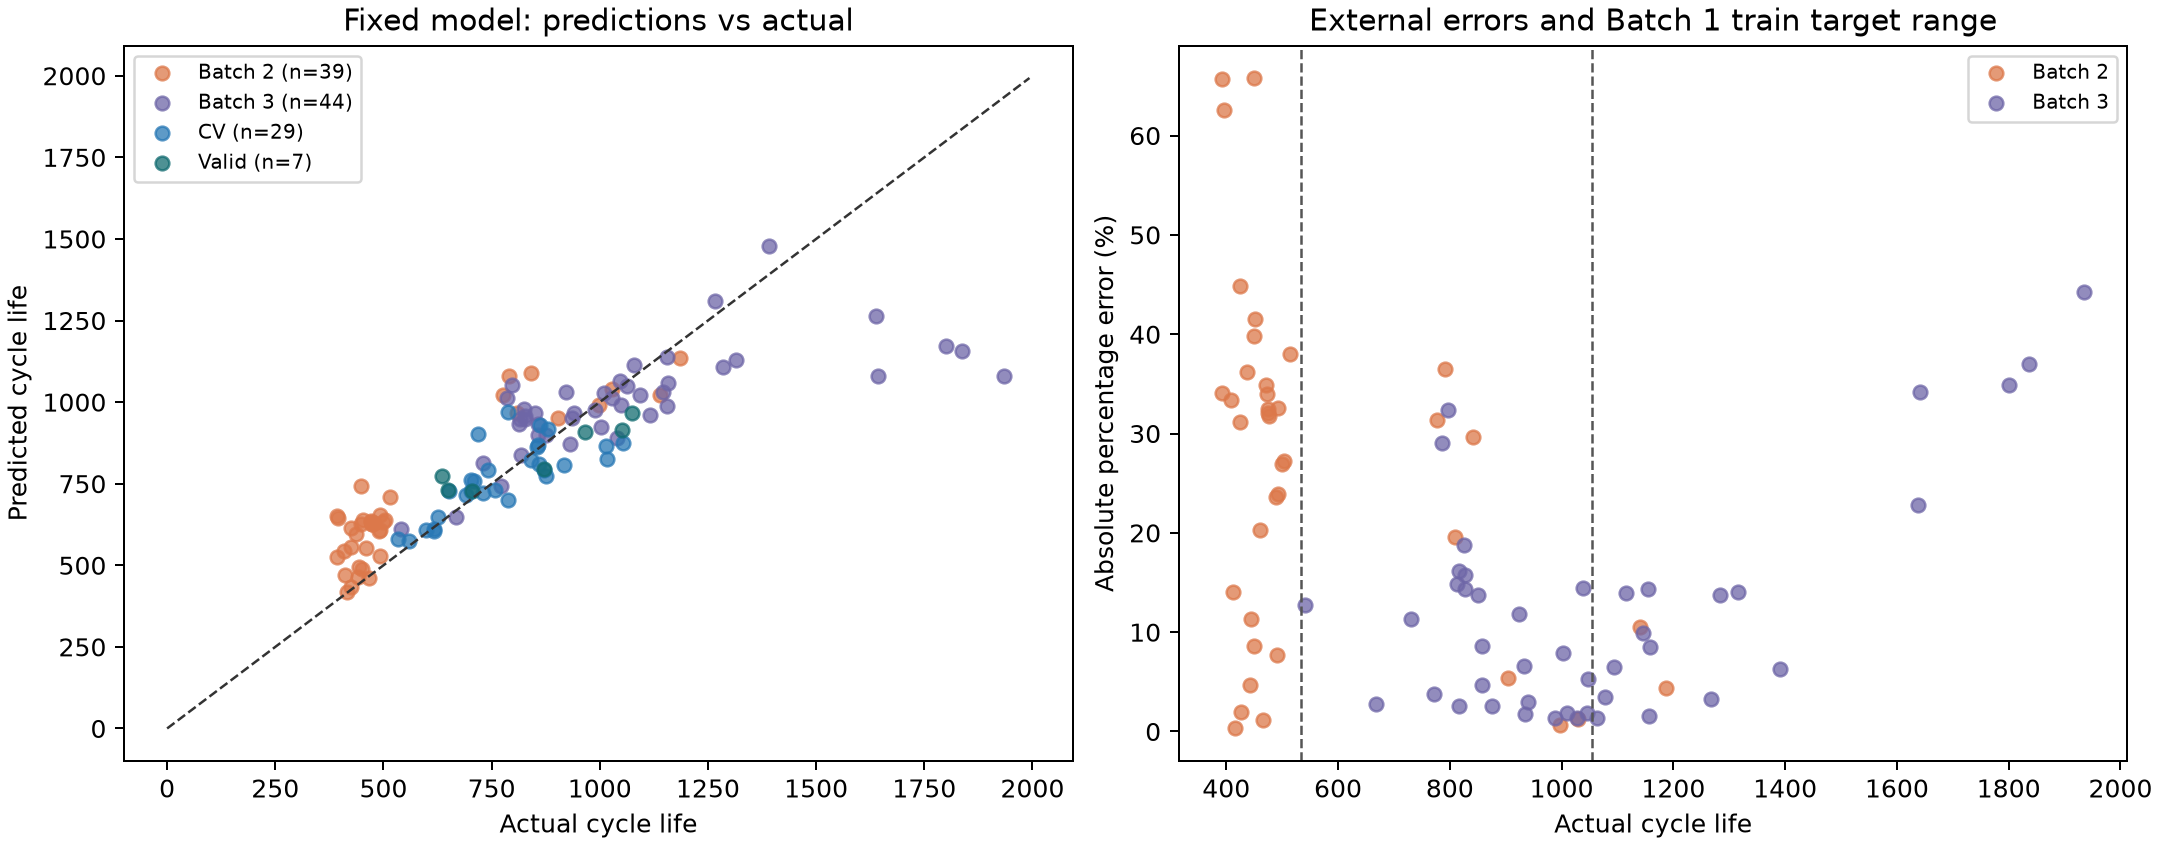

In [4]:
pred = pd.read_csv(ROOT / "results/day2_predictions.csv")
for batch in ["Batch 2", "Batch 3"]:
    part = pred[pred.phase == batch]
    print(batch, "실제 수명 구간별")
    display(part.groupby("target_range").agg(cells=("cell_id","size"), MAPE_pct=("absolute_percentage_error","mean"), mean_bias_cycles=("error_cycles","mean")).round(2))
print("Batch 2 오차 상위 10셀")
display(pred[pred.phase == "Batch 2"].nlargest(10,"absolute_percentage_error")[["cell_id","actual","predicted","absolute_percentage_error","policy_group"]].round(2))
display(Image(filename=str(ROOT / "results/day2_predictions_and_errors.png")))

## 5. 해석과 적용 한계

Batch 1 내부 결과와 Batch 2 결과의 차이가 크면, Batch 1에서 확인한 초기 신호가 다른 충전정책·수명 분포로 충분히 일반화되지 않았을 가능성을 살펴야 한다. 특히 짧은 수명 셀을 오래갈 것으로 예측하면 ESS 선별 시 추가 시험이 필요한 셀을 놓칠 수 있다.

Hold-out은 7셀, Batch 2는 9개 정책군에 그친다. 종료 QD 기준은 라벨 진실성을 보장하지 않고 일부 셀을 제외한다. DAY 1 EDA에서 외부 배치의 라벨 분포를 관찰했으므로 완전히 눈가림한 평가는 아니다. 실제 ESS 운전 적용 전에는 다른 온도·부분 충방전·캘린더 열화 조건에서 재검증해야 한다.

전체 결과·상위 오차 셀·성능 Gap은 [DAY 2 모델 평가 보고서](../report/DAY2_모델평가.md)에 정리했다.